# 8-2절 연습 문제 풀이

이 노트북은 8-2절 연습 문제(8-4 ~ 8-7)의 풀이 예시다.

- 본문 예제 코드는 `code_examples/ch08/08-02_example.ipynb`를 참고한다.
- 학습 환경과 데이터로더는 본문 예제와 같게 맞춰 결과를 그대로 견줄 수 있게 했다.
- 문제마다 **풀이 해설**과 **문제 검토**를 함께 실었다. 문제 검토는 최종 검토 3단계의 기록이다.

## 공통 준비 — 환경 설정, 데이터로더, 기준 모델, 학습 함수

In [1]:
# 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


In [2]:
# CIFAR-10 데이터로더 (본문 예제와 동일)
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

data_root = '../../download'

CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

TRAIN_SIZE, VALID_SIZE = 40000, 10000
BATCH_SIZE = 64

full_train_set = datasets.CIFAR10(root=data_root, train=True,
                                  download=True, transform=train_transform)
full_eval_set = datasets.CIFAR10(root=data_root, train=True,
                                 download=True, transform=transform)
test_set = datasets.CIFAR10(root=data_root, train=False,
                            download=True, transform=transform)

common.set_seed(SEED, deterministic=True)
train_set, valid_set = random_split(full_train_set, [TRAIN_SIZE, VALID_SIZE])
common.set_seed(SEED, deterministic=True)
train_evaluate_set, _ = random_split(full_eval_set, [TRAIN_SIZE, VALID_SIZE])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 {len(train_set)}, 검증 {len(valid_set)}, 평가 {len(test_set)}')

훈련 40000, 검증 10000, 평가 10000


In [3]:
# 기준 모델 MiniVGGNetBN ([코드 8-3]과 같음)
import torch.nn as nn


class MiniVGGNetBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32),               # (B, 3, 32, 32) -> (B, 32, 16, 16)
            vgg_block(32, 64),              #                -> (B, 64, 8, 8)
            vgg_block(64, 128)              #                -> (B, 128, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [4]:
# 학습에 사용하는 함수 (본문 예제와 동일)
import copy

import torch.optim as optim


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size


def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience, device):
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss, best_epoch, best_params, patience_counter = float('inf'), -1, None, 0
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        if valid_loss < best_valid_loss:
            best_valid_loss, best_epoch = valid_loss, epoch
            best_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    if best_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 복원')
        model.load_state_dict(best_params)
    return log, best_epoch


def run_training(model_factory, name, epochs=200, patience=10, lr=1e-3):
    common.set_seed(SEED, deterministic=True)
    model = model_factory()
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    print(f'{name} 학습')
    log, best_epoch = train_with_early_stopping(
        model, train_loader, valid_loader, criterion, optimizer,
        epochs, patience, device)
    train_loss, train_acc = evaluate(model, train_evaluate_loader, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    result = {'name': name, 'best_epoch': best_epoch,
              'train_loss': train_loss, 'test_loss': test_loss,
              'train_acc': train_acc * 100, 'test_acc': test_acc * 100,
              'params': common.count_params(model)}
    print(f"{name}: 최적 에포크 {best_epoch}, 훈련 손실 {train_loss:.4f} / "
          f"평가 손실 {test_loss:.4f}, 훈련 정확도 {train_acc * 100:.2f}% / "
          f"평가 정확도 {test_acc * 100:.2f}%")
    return model, result


def print_results(results, keys):
    print(f"{'모델':<24}{'최적 에포크':>10}{'훈련 손실':>10}{'평가 손실':>10}"
          f"{'훈련 정확도':>12}{'평가 정확도':>12}{'파라미터':>12}")
    print('-' * 90)
    for k in keys:
        r = results[k]
        print(f"{r['name']:<24}{r['best_epoch']:>10}{r['train_loss']:>10.4f}"
              f"{r['test_loss']:>10.4f}{r['train_acc']:>11.2f}%{r['test_acc']:>11.2f}%"
              f"{r['params']:>12,}")


EPOCHS = 200
PATIENCE = 10
LR = 1e-3
results = {}

---

## 연습 문제 8-4

> `MiniVGGNetBN` 모델에서 일부 배치 정규화 계층만 `affine=False`로 설정했을 때 학습 가능한
> 파라미터의 수가 어떻게 바뀌는지 `torchinfo.summary()`를 사용해 확인해 보자.

In [5]:
# affine 인자를 블록별로 지정할 수 있게 만든 MiniVGGNetBN
class MiniVGGNetBNAffine(nn.Module):
    def __init__(self, affine_flags=(True, True, True), num_classes=10):
        """affine_flags: 세 VGG 블록의 배치 정규화 계층에 줄 affine 인자"""
        super().__init__()

        def vgg_block(in_channels, out_channels, affine):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels, affine=affine),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels, affine=affine),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32, affine_flags[0]),
            vgg_block(32, 64, affine_flags[1]),
            vgg_block(64, 128, affine_flags[2])
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
# torchinfo.summary()로 파라미터 수 비교
from torchinfo import summary

cases = [
    ('모두 affine=True(기본값)', (True, True, True)),
    ('첫 번째 블록만 affine=False', (False, True, True)),
    ('세 번째 블록만 affine=False', (True, True, False)),
    ('모두 affine=False', (False, False, False)),
]

print(f"{'설정':<28}{'전체':>12}{'학습 가능':>12}{'학습 불가':>12}{'기준 대비':>12}")
print('-' * 76)
base = None
for label, flags in cases:
    info = summary(MiniVGGNetBNAffine(flags), input_size=(64, 3, 32, 32),
                   device='cpu', verbose=0)
    non_trainable = info.total_params - info.trainable_params
    if base is None:
        base = info.total_params
    print(f'{label:<28}{info.total_params:>12,}{info.trainable_params:>12,}'
          f'{non_trainable:>12,}{info.total_params - base:>12,}')


설정                                    전체       학습 가능       학습 불가       기준 대비
----------------------------------------------------------------------------
모두 affine=True(기본값)              551,018     551,018           0           0
첫 번째 블록만 affine=False            550,890     550,890           0        -128
세 번째 블록만 affine=False            550,506     550,506           0        -512
모두 affine=False                  550,122     550,122           0        -896


In [7]:
# 줄어든 파라미터가 어디서 왔는지 확인
model = MiniVGGNetBNAffine((True, True, True))
print('배치 정규화 계층별 파라미터와 버퍼')
print(f"{'계층':<12}{'채널':>6}{'파라미터(γ, β)':>16}{'버퍼(이동평균, 이동분산)':>26}")
print('-' * 62)
total_affine = 0
for name, module in model.named_modules():
    if isinstance(module, nn.BatchNorm2d):
        params = sum(p.numel() for p in module.parameters())
        buffers = sum(b.numel() for b in module.buffers()
                      if b.dtype.is_floating_point)
        total_affine += params
        print(f'{name:<12}{module.num_features:>6}{params:>16,}{buffers:>26,}')
print('-' * 62)
print(f'{"합계":<12}{"":>6}{total_affine:>16,}')

print()
print('블록별 크기/위치 파라미터')
for i, channels in enumerate(((32, 32), (64, 64), (128, 128)), start=1):
    print(f'  {i}번째 블록: 2 x ({channels[0]} + {channels[1]}) = '
          f'{2 * sum(channels)}개')


배치 정규화 계층별 파라미터와 버퍼
계층              채널      파라미터(γ, β)            버퍼(이동평균, 이동분산)
--------------------------------------------------------------
features.0.1    32              64                        64
features.0.4    32              64                        64
features.1.1    64             128                       128
features.1.4    64             128                       128
features.2.1   128             256                       256
features.2.4   128             256                       256
--------------------------------------------------------------
합계                             896

블록별 크기/위치 파라미터
  1번째 블록: 2 x (32 + 32) = 128개
  2번째 블록: 2 x (64 + 64) = 256개
  3번째 블록: 2 x (128 + 128) = 512개


### 풀이 해설 — 연습 문제 8-4

`nn.BatchNorm2d(C)`는 `affine=True`(기본값)일 때 채널마다 크기 파라미터(γ)와 위치 파라미터(β)를
하나씩 갖는다. 따라서 계층 하나가 갖는 학습 가능한 파라미터는 **2C개**다.

`MiniVGGNetBN`의 배치 정규화 계층은 채널 수가 32, 32, 64, 64, 128, 128이므로 크기/위치
파라미터의 합은 `2 x (32 + 32 + 64 + 64 + 128 + 128) = 896`개다. 블록별로는 첫 번째 블록이
128개, 두 번째 블록이 256개, 세 번째 블록이 512개다. **같은 개수의 계층을 꺼도 뒤쪽 블록일수록
줄어드는 파라미터가 많다.** 채널 수가 두 배씩 늘어나기 때문이다.

**여기서 꼭 짚어야 할 것이 하나 있다.** `affine=False`로 바꾸면 γ와 β가 **아예 만들어지지 않는다.**
그래서 `Trainable params`뿐 아니라 `Total params`도 함께 줄고, **`Non-trainable params`는 0에서
움직이지 않는다.**

배치 정규화 계층이 평가 모드에서 쓰는 이동평균과 이동분산은 어떻게 될까? 이 값들은 채널마다
하나씩 있지만 **파라미터가 아니라 버퍼**다. 학습으로 최적화하는 대상이 아니라 순전파 도중에
누적되는 통계값이라, `torchinfo.summary()`의 세 줄 어디에도 잡히지 않는다. 8-1절 각주가
`Non-trainable params`를 두고 "`requires_grad=False` 등으로 값을 고정한 파라미터가 여기에
속한다"고 설명한 것과 맞물린다. `affine=False`는 파라미터를 **고정하는** 것이 아니라
**없애는** 것이므로 그 줄과는 무관하다.

`affine=False`로 껐을 때 무엇을 잃는지도 생각해 볼 만하다. 8-2절 본문은 "무조건 평균 0과
표준편차 1로 고정하는 게 항상 정답은 아니다"라며 γ와 β를 도입했다. `affine=False`는 그 조정
능력을 포기하고 모든 계층의 출력을 평균 0, 표준편차 1에 묶어 두겠다는 선택이다. 파라미터
896개를 아끼는 대신 모델의 유연함이 줄어든다.


---

## 연습 문제 8-5

> `MiniVGGNetBN` 모델의 분류기에 앞서 삭제했던 드롭아웃 계층을 다시 추가해 학습해 보자.
> 학습 과정과 성능이 어떻게 달라지는지 관찰하고, 그 이유를 설명해 보자.

In [8]:
# 분류기에 드롭아웃 계층을 되살린 모델
class MiniVGGNetBNDropout(MiniVGGNetBN):
    def __init__(self, num_classes=10, p=0.5):
        super().__init__(num_classes)
        # [코드 8-1]의 MiniVGGNet과 같은 자리에 드롭아웃 계층을 다시 넣는다
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(128, num_classes)
        )


model_bn, results['BN'] = run_training(MiniVGGNetBN, 'MiniVGGNetBN', EPOCHS, PATIENCE, LR)

MiniVGGNetBN 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4097       1.4113       49.23%     0:14


  2/200       0.9568       0.8482       69.95%     0:28


  3/200       0.7884       0.7327       73.90%     0:42


  4/200       0.6975       0.7755       73.19%     0:57


...

 31/200       0.2265       0.4442       86.14%     7:05


 32/200       0.2172       0.4444       85.59%     7:19


 33/200       0.2151       0.4126       85.91%     7:33


 34/200       0.2044       0.4218       86.42%     7:46
최적 에포크(24, 최소 검증 손실 0.4100)의 파라미터로 복원


MiniVGGNetBN: 최적 에포크 24, 훈련 손실 0.2105 / 평가 손실 0.4189, 훈련 정확도 92.55% / 평가 정확도 86.42%


In [9]:
model_bn_do, results['BN+Dropout'] = run_training(
    MiniVGGNetBNDropout, 'MiniVGGNetBN+드롭아웃', EPOCHS, PATIENCE, LR)

MiniVGGNetBN+드롭아웃 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.6794       1.4540       47.72%     0:14


  2/200       1.3414       1.0701       61.49%     0:27


  3/200       1.1607       1.2359       57.06%     0:41


  4/200       1.0652       0.9698       65.06%     0:55


...

 51/200       0.2364       0.4307       86.54%    11:33


 52/200       0.2270       0.4275       87.39%    11:47


 53/200       0.2269       0.4833       85.96%    12:01


 54/200       0.2256       0.4774       86.01%    12:14
최적 에포크(44, 최소 검증 손실 0.4160)의 파라미터로 복원


MiniVGGNetBN+드롭아웃: 최적 에포크 44, 훈련 손실 0.1650 / 평가 손실 0.4327, 훈련 정확도 94.13% / 평가 정확도 87.30%


In [10]:
print_results(results, ['BN', 'BN+Dropout'])

모델                          최적 에포크     훈련 손실     평가 손실      훈련 정확도      평가 정확도        파라미터
------------------------------------------------------------------------------------------
MiniVGGNetBN                    24    0.2105    0.4189      92.55%      86.42%     551,018
MiniVGGNetBN+드롭아웃               44    0.1650    0.4327      94.13%      87.30%     551,018


### 풀이 해설 — 연습 문제 8-5

실행 결과는 다음과 같다.

| 모델 | 최적 에포크 | 훈련 손실 | 평가 손실 | 훈련 정확도 | 평가 정확도 |
|---|---|---|---|---|---|
| `MiniVGGNetBN` | 24 | 0.2105 | 0.4189 | 92.55% | 86.42% |
| + 드롭아웃 | **44** | 0.1650 | 0.4327 | 94.13% | **87.30%** |

**본문 각주가 예고한 두 가지가 그대로 나타났다.**

1. **최적 에포크가 24에서 44로 거의 두 배가 되었다.** 드롭아웃은 학습 모드에서 매 배치마다 뉴런의
   절반을 꺼 버리므로, 한 에포크에서 각 파라미터가 받는 갱신 신호가 줄어든다. 같은 수준의 검증
   손실에 도달하기까지 더 많은 에포크가 필요해진다.
2. **평가 정확도는 0.88%p 올랐다**(86.42% → 87.30%). 드롭아웃이 특정 뉴런에 의존하지 못하게
   막아 일반화를 돕는다.

각주가 "드롭아웃을 그대로 두면 모델 성능은 올라가지만, 매 배치마다 일부 뉴런이 비활성화되는
만큼 학습이 더디게 진행되어 전체 학습 에포크도 길어진다"고 한 그대로다.

**한 가지 예상과 다른 점이 있다.** 드롭아웃이 일반화를 돕는다면 훈련 손실과 평가 손실의 간격이
좁아질 법한데, 실제로는 **오히려 벌어졌다**(0.2084 → 0.2677). 훈련 정확도도 92.55%에서
94.13%로 더 많이 올랐다.

이유는 1번과 맞물려 있다. 드롭아웃 덕분에 **과적합이 늦게 시작되어 조기 종료가 44 에포크까지
학습을 허용했고**, 그만큼 모델이 훈련 데이터에 더 깊이 맞춰졌다. 즉 드롭아웃은 훈련/평가 격차
자체를 줄였다기보다 **더 오래 학습해도 평가 성능이 나빠지지 않게 버텨 준** 셈이다. 그 결과가
0.88%p의 정확도 향상이다.

**그러나 얻은 것에 비해 치른 비용이 크다.** 에포크가 두 배가 되어 학습 시간도 두 배가 들었는데
정확도는 1%p가 채 되지 않는다. 8-2절 본문이 "배치 정규화 계층이 충분히 들어 있는 모델은
드롭아웃의 비율을 줄이거나 빼더라도 대부분 일반화 성능에 큰 차이가 없다"며 `MiniVGGNetBN`에서
드롭아웃을 뺀 판단이 수치로 뒷받침된다.


---

## 연습 문제 8-6

> 배치 정규화 계층 덕분에 성능 저하 없이 더 깊은 신경망을 만들 수 있는지 `MiniVGGNetBN` 모델을
> [연습 문제 8-2]처럼 다음 두 가지 방향으로 각각 수정해 직접 확인해 보자.
> - VGG 블록에 합성곱 계층, 배치 정규화 계층, ReLU 활성화 계층 한 묶음 더 추가한 모델
> - 특징 추출기 계층(`features`)에 VGG 블록을 하나 더 추가한 모델

In [11]:
# (1) VGG 블록마다 합성곱 + 배치 정규화 + ReLU 한 묶음을 더 추가 (합성곱 6개 -> 9개)
class MiniVGGNetBNDeepBlock(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def conv_bn_relu(in_channels, out_channels):
            return [
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            ]

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                *conv_bn_relu(in_channels, out_channels),
                *conv_bn_relu(out_channels, out_channels),
                *conv_bn_relu(out_channels, out_channels),   # 추가한 한 묶음
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32), vgg_block(32, 64), vgg_block(64, 128)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# (2) 특징 추출기에 VGG 블록을 하나 더 추가 (합성곱 6개 -> 8개)
class MiniVGGNetBNExtraBlock(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32), vgg_block(32, 64),
            vgg_block(64, 128), vgg_block(128, 256)   # 추가한 블록, (B, 256, 2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [12]:
model_bn_deep, results['BN-DeepBlock'] = run_training(
    MiniVGGNetBNDeepBlock, 'MiniVGGNetBN 블록 심화', EPOCHS, PATIENCE, LR)

MiniVGGNetBN 블록 심화 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4934       1.2727       55.29%     0:14


  2/200       1.0586       0.9910       65.08%     0:29


  3/200       0.8620       0.8635       69.94%     0:44


  4/200       0.7392       0.7228       74.40%     0:59


...

 42/200       0.1416       0.4312       87.48%    10:13


 43/200       0.1431       0.4156       88.11%    10:27


 44/200       0.1387       0.4408       87.43%    10:42


 45/200       0.1272       0.4132       87.68%    10:56
최적 에포크(35, 최소 검증 손실 0.4009)의 파라미터로 복원


MiniVGGNetBN 블록 심화: 최적 에포크 35, 훈련 손실 0.1256 / 평가 손실 0.3960, 훈련 정확도 95.59% / 평가 정확도 88.42%


In [13]:
model_bn_extra, results['BN-ExtraBlock'] = run_training(
    MiniVGGNetBNExtraBlock, 'MiniVGGNetBN 블록 추가', EPOCHS, PATIENCE, LR)

MiniVGGNetBN 블록 추가 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.4455       1.2183       56.21%     0:14


  2/200       0.9740       0.8701       68.48%     0:28


  3/200       0.7793       0.7648       73.57%     0:43


  4/200       0.6798       0.6708       76.76%     0:56


...

 30/200       0.1739       0.4495       86.54%     6:59


 31/200       0.1778       0.4196       87.09%     7:14


 32/200       0.1641       0.4227       87.42%     7:28


 33/200       0.1603       0.4263       87.38%     7:42
최적 에포크(23, 최소 검증 손실 0.4040)의 파라미터로 복원


MiniVGGNetBN 블록 추가: 최적 에포크 23, 훈련 손실 0.1739 / 평가 손실 0.4007, 훈련 정확도 93.97% / 평가 정확도 87.31%


In [14]:
print_results(results, ['BN', 'BN-DeepBlock', 'BN-ExtraBlock'])

모델                          최적 에포크     훈련 손실     평가 손실      훈련 정확도      평가 정확도        파라미터
------------------------------------------------------------------------------------------
MiniVGGNetBN                    24    0.2105    0.4189      92.55%      86.42%     551,018
MiniVGGNetBN 블록 심화              35    0.1256    0.3960      95.59%      88.42%     745,002
MiniVGGNetBN 블록 추가              23    0.1739    0.4007      93.97%      87.31%   1,305,706


### 풀이 해설 — 연습 문제 8-6

[연습 문제 8-2]와 같은 두 방향으로 깊게 만들되, 이번에는 배치 정규화 계층이 함께 들어간다.
8-2에서 성능이 떨어졌던 두 변형이 이번에는 어떻게 되는지를 견주는 것이 이 문제의 목적이다.

읽을 때 주의할 점이 있다. **두 변형의 성격이 서로 다르다.**

- **블록 심화**는 특징 지도의 크기를 바꾸지 않고 합성곱 계층만 늘린다. 배치 정규화의 효과가
  그대로 드러나는 조건이다.
- **블록 추가**는 풀링이 한 번 더 들어가 특징 지도가 2x2까지 줄어든다. 배치 정규화와 무관하게
  CIFAR-10의 32x32 해상도 자체가 한계로 작용한다.

따라서 블록 추가 쪽에서 성능이 오르지 않더라도 그것이 곧 "배치 정규화로도 깊이의 한계를 넘지
못한다"는 뜻은 아니다. 배치 정규화의 효과를 판단하려면 블록 심화 쪽을 [연습 문제 8-2]의 같은
변형과 비교해야 한다. 실행 결과는 위 표로 확인한다.

---

## 연습 문제 8-7 [도전 문제]

> [연습 문제 8-3]에서 만든 VGGNet 기반의 오토인코더 모델을 수정해 배치 정규화 계층을 추가해
> 보자. 학습한 오토인코더가 배치 정규화 계층 유무에 따라 결과가 어떻게 다른지 비교하고,
> 그 결과를 배치 정규화 계층의 역할을 기준으로 설명해 보자.

In [15]:
# 오토인코더용 데이터로더 (증강 없음)
ae_train_set, ae_valid_set = random_split(
    datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform),
    [TRAIN_SIZE, VALID_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)
ae_train_loader = DataLoader(ae_train_set, batch_size=BATCH_SIZE, shuffle=True)
ae_valid_loader = DataLoader(ae_valid_set, batch_size=BATCH_SIZE, shuffle=False)
ae_test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


# [연습 문제 8-3]의 오토인코더에 배치 정규화 계층을 켜고 끌 수 있게 만든 모델
class VGGConvAutoEncoder(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        def conv(in_channels, out_channels):
            layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                padding=1, bias=not use_bn)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            return layers

        def up(in_channels, out_channels):
            layers = [nn.ConvTranspose2d(in_channels, out_channels,
                                         kernel_size=2, stride=2)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU())
            return layers

        self.encoder = nn.Sequential(
            *conv(3, 32), *conv(32, 32), nn.MaxPool2d(2, 2),     # (B, 32, 16, 16)
            *conv(32, 64), *conv(64, 64), nn.MaxPool2d(2, 2),    # (B, 64, 8, 8)
            *conv(64, 128), *conv(128, 128), nn.MaxPool2d(2, 2), # (B, 128, 4, 4)
        )
        self.decoder = nn.Sequential(
            *up(128, 64), *conv(64, 64), *conv(64, 64),          # (B, 64, 8, 8)
            *up(64, 32), *conv(32, 32), *conv(32, 32),           # (B, 32, 16, 16)
            *up(32, 32), *conv(32, 32), *conv(32, 32),           # (B, 32, 32, 32)
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


for flag in (False, True):
    m = VGGConvAutoEncoder(use_bn=flag)
    print(f'use_bn={flag}: 출력 형태 {tuple(m(torch.randn(2, 3, 32, 32)).shape)}, '
          f'파라미터 {common.count_params(m):,}개')

use_bn=False: 출력 형태 (2, 3, 32, 32), 파라미터 443,907개
use_bn=True: 출력 형태 (2, 3, 32, 32), 파라미터 444,867개


In [16]:
# 오토인코더 학습 함수
AE_EPOCHS = 40
AE_PATIENCE = 5


@torch.no_grad()
def evaluate_ae(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        loss = criterion(model(inputs), inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


def train_autoencoder(use_bn, name, epochs=AE_EPOCHS, patience=AE_PATIENCE, lr=1e-3):
    common.set_seed(SEED, deterministic=True)
    model = VGGConvAutoEncoder(use_bn=use_bn)
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    log = common.EpochLogger(epochs, columns=('훈련 MSE', '검증 MSE'),
                             formats=('{:.6f}', '{:.6f}'),
                             target_rows=epochs, minimize='검증 MSE')
    best_valid_loss, best_epoch, best_params, patience_counter = float('inf'), -1, None, 0
    print(f'{name} 학습')
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, sample_size = 0.0, 0
        for inputs, _ in ae_train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), inputs)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * inputs.size(0)
            sample_size += inputs.size(0)
        valid_loss = evaluate_ae(model, ae_valid_loader, criterion, device)
        log.row(epoch, loss_sum / sample_size, valid_loss)
        if valid_loss < best_valid_loss:
            best_valid_loss, best_epoch = valid_loss, epoch
            best_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    if best_params is not None:
        model.load_state_dict(best_params)
    test_loss = evaluate_ae(model, ae_test_loader, criterion, device)
    print(f'{name}: 최적 에포크 {best_epoch}, 검증 MSE {best_valid_loss:.6f}, '
          f'평가 MSE {test_loss:.6f}')
    return model, {'name': name, 'best_epoch': best_epoch,
                   'valid_mse': best_valid_loss, 'test_mse': test_loss,
                   'params': common.count_params(model)}

In [17]:
ae_results = {}
ae_plain, ae_results['plain'] = train_autoencoder(False, '오토인코더(배치 정규화 없음)')

오토인코더(배치 정규화 없음) 학습


에포크     훈련 MSE     검증 MSE     시간
  1/40     0.075360     0.051259     0:10


  2/40     0.043296     0.031960     0:22


  3/40     0.029186     0.026291     0:32


  4/40     0.022998     0.021071     0:42


...

 37/40     0.007464     0.007256     6:11


 38/40     0.007351     0.007514     6:21


 39/40     0.007273     0.007564     6:30


 40/40     0.006964     0.006575     6:40


오토인코더(배치 정규화 없음): 최적 에포크 40, 검증 MSE 0.006575, 평가 MSE 0.006505


In [18]:
ae_bn, ae_results['bn'] = train_autoencoder(True, '오토인코더(배치 정규화 있음)')

오토인코더(배치 정규화 있음) 학습


에포크     훈련 MSE     검증 MSE     시간
  1/40     0.042694     0.025683     0:11


  2/40     0.021224     0.018358     0:22


  3/40     0.017084     0.014505     0:32


  4/40     0.015181     0.015472     0:43


...

  9/40     0.011609     0.017933     1:37


 10/40     0.011054     0.011536     1:48


 11/40     0.010482     0.012410     1:58


 12/40     0.009976     0.013041     2:09


오토인코더(배치 정규화 있음): 최적 에포크 7, 검증 MSE 0.011520, 평가 MSE 0.011424


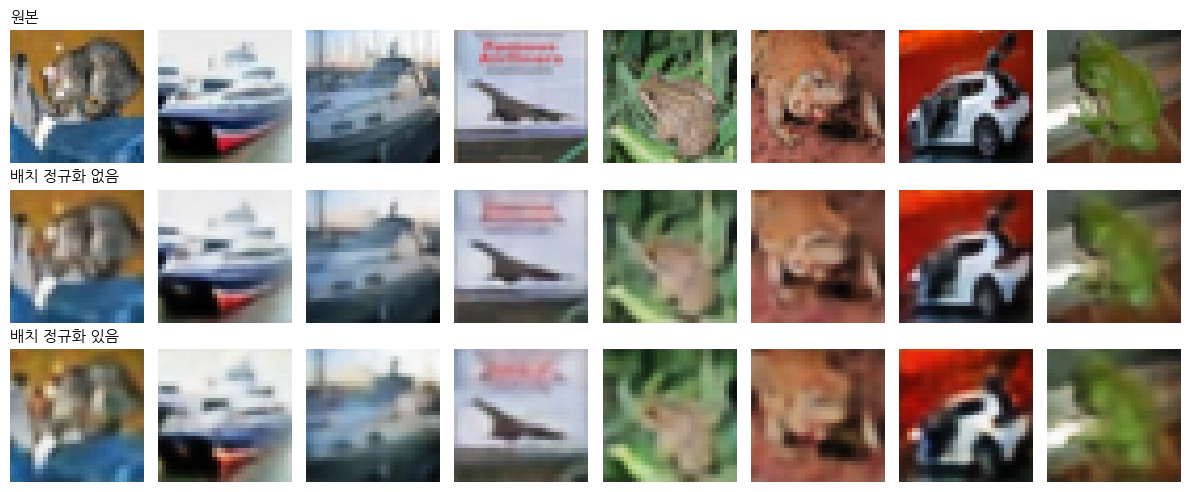

모델                              최적 에포크      평가 MSE        파라미터
--------------------------------------------------------------
오토인코더(배치 정규화 없음)                    40    0.006505     443,907
오토인코더(배치 정규화 있음)                     7    0.011424     444,867


In [19]:
# 복원 결과 비교
import matplotlib.pyplot as plt


@torch.no_grad()
def reconstruct(model, images):
    model.eval()
    return model(images.to(device)).cpu()


def to_image(tensor):
    return tensor.permute(1, 2, 0).clamp(-1, 1).mul(0.5).add(0.5).numpy()


sample_images = torch.stack([test_set[i][0] for i in range(8)])
rows = [(sample_images, '원본'),
        (reconstruct(ae_plain, sample_images), '배치 정규화 없음'),
        (reconstruct(ae_bn, sample_images), '배치 정규화 있음')]

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for row, (images, title) in enumerate(rows):
    for col in range(8):
        axes[row, col].imshow(to_image(images[col]))
        axes[row, col].axis('off')
    axes[row, 0].set_title(title, loc='left', fontsize=11)
fig.tight_layout()
plt.show()

print(f"{'모델':<28}{'최적 에포크':>10}{'평가 MSE':>12}{'파라미터':>12}")
print('-' * 62)
for key in ('plain', 'bn'):
    r = ae_results[key]
    print(f"{r['name']:<28}{r['best_epoch']:>10}{r['test_mse']:>12.6f}{r['params']:>12,}")

### 풀이 해설 — 연습 문제 8-7

실행 결과는 다음과 같다.

| 모델 | 최적 에포크 | 평가 MSE | 파라미터 |
|---|---|---|---|
| 배치 정규화 없음 | 40 (예산 소진) | **0.006505** | 443,907 |
| 배치 정규화 있음 | 7 (12에서 조기 종료) | 0.011424 | 444,867 |

**최종 MSE만 보면 배치 정규화를 넣은 쪽이 더 나쁘다.** 그런데 에포크별 기록을 보면 이야기가
달라진다.

| 에포크 | 훈련 MSE (없음) | 훈련 MSE (있음) | 검증 MSE (없음) | 검증 MSE (있음) |
|---|---|---|---|---|
| 1 | 0.075360 | **0.042694** | 0.051259 | **0.025683** |
| 3 | 0.029186 | **0.017084** | 0.026291 | **0.014505** |
| 7 | 0.017289 | **0.012600** | 0.016004 | **0.011520** |
| 12 | 0.012524 | **0.009976** | 0.014469 | 0.013041 |

**배치 정규화는 학습을 확실히 가속했다.** 훈련 MSE 기준으로 12 에포크 만에 도달한 수준(0.009976)을
배치 정규화 없는 모델은 30 에포크를 넘겨서야 따라잡는다. 8-2절 본문이 말한 "안정되고 더 빠른
학습"이 그대로 나타난다.

**문제는 검증 MSE다.** 8 에포크부터 0.014991 → 0.017933 → 0.011536 → 0.012410 → 0.013041로
**요동치기 시작해** 참을성 한계 5에 걸려 12 에포크에서 멈췄다. 훈련 MSE는 계속 내려가는데
검증 MSE만 흔들린 것이다.

**이 어긋남이 배치 정규화의 역할에서 나온다.** 배치 정규화는 학습 모드에서는 배치별 통계로,
평가 모드에서는 학습 중 누적한 이동평균과 이동분산으로 정규화한다. 분류에서는 이 차이가
크게 문제되지 않는다. 어느 클래스인지만 맞히면 되기 때문이다. 그러나 **복원은 입력값의
절대적인 크기 자체를 되살려야 하는 과제라서**, 두 모드의 통계가 조금만 어긋나도 복원 이미지의
밝기와 대비가 통째로 밀린다. 학습이 진행되며 이동 통계가 자리를 잡기 전까지 검증 MSE가
요동치는 이유다.

**결론: 이 실험에서 배치 정규화는 학습 속도에는 도움이 되었지만 복원 품질에는 도움이 되지
않았다.** 8-3절이 다룰 "배치 정규화의 부작용"을 오토인코더에서 미리 만나는 셈이다.

다만 해석에 단서를 달아야 한다. 배치 정규화 없는 모델은 40 에포크 예산을 다 쓰고도 아직
수렴하지 않았고, 배치 정규화를 넣은 모델은 참을성 한계 5에 걸려 일찍 멈췄다. **참을성 한계를
더 크게 주면 배치 정규화 쪽이 요동을 지나 더 내려갔을 가능성이 있다.** 두 모델을 같은 조건으로
맞춰 비교한 결과이되, 어느 쪽도 수렴한 상태는 아니다.
